# Cityscapes Dataset Exploration

Quick notebook to inspect splits, file counts, and visualize sample images + annotations.

In [7]:
import os
import glob
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import sys
sys.path.append("./DeepLabV3Plus-Pytorch")

import torch
import torch.nn as nn
from torchvision import transforms as T

import network
import utils
from datasets import VOCSegmentation, Cityscapes

In [8]:
# Adjust this path if needed
cityscapes_path = "/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/perceptionmetrics/local/data/cityscapes"
gt_dir = os.path.join(cityscapes_path, 'gtFine')
img_dir = os.path.join(cityscapes_path, 'leftImg8bit_trainvaltest')
print('gtFine exists:', os.path.isdir(gt_dir))
print('leftImg8bit_trainvaltest exists:', os.path.isdir(img_dir))

gtFine exists: True
leftImg8bit_trainvaltest exists: True


In [9]:
# List available splits and the cities
for folder in ['train', 'val', 'test']:
    p = os.path.join(gt_dir, folder)
    if os.path.isdir(p):
        cities = sorted(os.listdir(p))
        print(f'{folder}: {len(cities)} cities, sample:', cities[:])
    else:
        print(f'{folder}: not present')
        
## label name example: gtFine_trainvaltest/gtFine/val/frankfurt/frankfurt_000000_000294_gtFine_labelIds.png
## image name example: leftImg8bit_trainvaltest/leftImg8bit/val/frankfurt/frankfurt_000000_000294_leftImg8bit.png

train: 18 cities, sample: ['aachen', 'bochum', 'bremen', 'cologne', 'darmstadt', 'dusseldorf', 'erfurt', 'hamburg', 'hanover', 'jena', 'krefeld', 'monchengladbach', 'strasbourg', 'stuttgart', 'tubingen', 'ulm', 'weimar', 'zurich']
val: 3 cities, sample: ['frankfurt', 'lindau', 'munster']
test: 6 cities, sample: ['berlin', 'bielefeld', 'bonn', 'leverkusen', 'mainz', 'munich']


In [10]:
# Count files by extension under gtFine and images

def count_files(root, pattern='**/*'):
    return sum(1 for _ in Path(root).rglob(pattern) if _.is_file())

print('gtFine total files:', count_files(gt_dir))
print('leftImg8bit_trainvaltest total files:', count_files(img_dir))

val_dir = os.path.join(gt_dir, 'val')
print('gtFine/val files:', count_files(val_dir))

gtFine total files: 20000
leftImg8bit_trainvaltest total files: 5002
gtFine/val files: 2000


Image: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/perceptionmetrics/local/data/cityscapes/leftImg8bit_trainvaltest/leftImg8bit/train/cologne/cologne_000004_000019_leftImg8bit.png
GT: /home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/PerceptionMetrics/perceptionmetrics/local/data/cityscapes/gtFine/train/cologne/cologne_000004_000019_gtFine_labelIds.png
Image size: (2048, 1024)


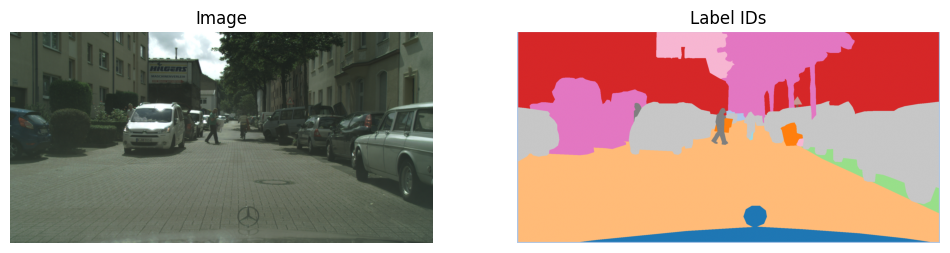

In [11]:
# Show a sample image and its corresponding labelIds annotation
def find_corresponding_gt(image_path):
    # image_path example:
    # .../leftImg8bit_trainvaltest/leftImg8bit/train/weimar/weimar_000072_000019_leftImg8bit.png
    path = Path(image_path)
    parts = path.parts

    try:
        idx = parts.index('leftImg8bit_trainvaltest')
        rel_parts = parts[idx + 1 :]
        if rel_parts and rel_parts[0] == 'leftImg8bit':
            rel_parts = rel_parts[1:]
    except ValueError:
        try:
            idx = parts.index('leftImg8bit')
            rel_parts = parts[idx + 1 :]
        except ValueError:
            return None

    if len(rel_parts) < 3:
        return None

    split = rel_parts[0]
    city = rel_parts[1]
    image_name = rel_parts[-1]
    base_name = image_name.replace('_leftImg8bit.png', '')
    search_dir = Path(gt_dir) / split / city

    fp = search_dir / f'{base_name}_gtFine_labelIds.png'
    if fp.exists():
        return str(fp)

    for fp in search_dir.glob(base_name + '*'):
        if fp.is_file():
            return str(fp)

    return None


def show_sample(split='train'):
    img_search = Path(img_dir) / 'leftImg8bit' / split
    cities = [d for d in img_search.iterdir() if d.is_dir()]
    if not cities:
        print('No cities found in', img_search)
        return
    city = random.choice(cities)
    imgs = list(city.glob('*_leftImg8bit.png'))
    if not imgs:
        print('No images in', city)
        return
    img_path = str(random.choice(imgs))
    gt_path = find_corresponding_gt(img_path)
    print('Image:', img_path)
    print('GT:', gt_path)
    img = Image.open(img_path).convert('RGB')
    # I need shape here to display the image, but I won't use it for evaluation
    print ('Image size:', img.size)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('Image')
    plt.imshow(img)
    plt.axis('off')
    if gt_path is not None:
        gt = Image.open(gt_path)
        plt.subplot(1, 2, 2)
        plt.title('Label IDs')
        plt.imshow(gt, cmap='tab20')
        plt.axis('off')
    plt.show()

# show one sample
show_sample('train')

In [ ]:
model_name = "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"

processor = AutoImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

cfg = processor.to_dict()

for key in cfg.keys():
    print(f'{key}: {cfg[key]}')

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

dict_keys(['do_normalize', 'do_resize', 'image_mean', 'image_std', 'reduce_labels', 'resample', 'size', 'do_rescale', 'rescale_factor', 'do_reduce_labels', 'image_processor_type'])
do_normalize: True
do_resize: True
image_mean: (0.485, 0.456, 0.406)
image_std: (0.229, 0.224, 0.225)
reduce_labels: False
resample: 2
size: {'height': 512, 'width': 512}
do_rescale: True
rescale_factor: 0.00392156862745098
do_reduce_labels: False
image_processor_type: SegformerImageProcessor


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[ 0  1  2  3  4  5  7  8  9 10 11 18] unique values in prediction


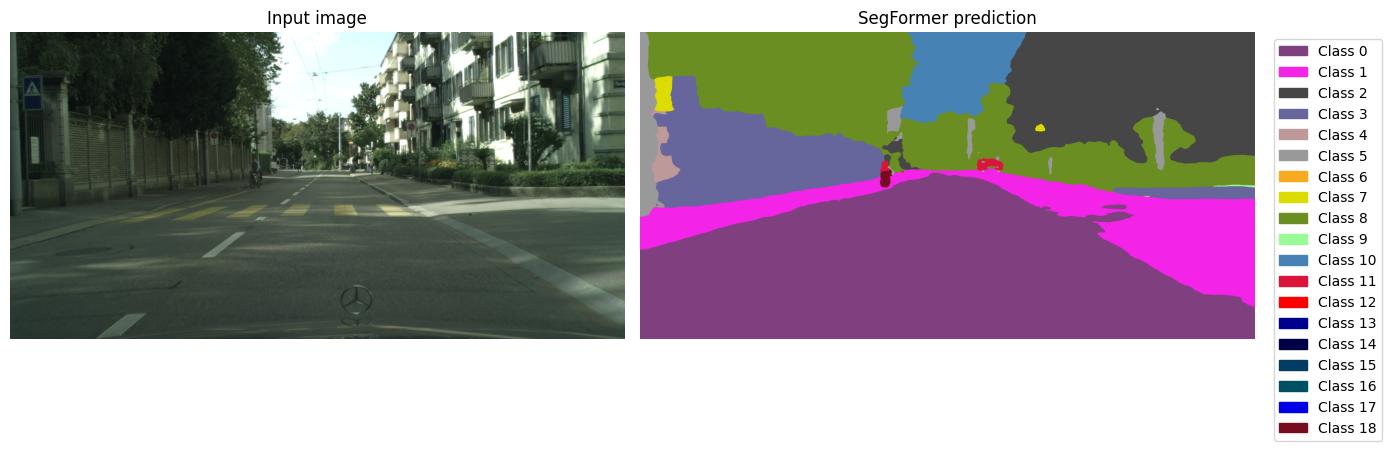

In [16]:
from PIL import Image
import torch
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation

model_name = "nvidia/segformer-b0-finetuned-cityscapes-1024-1024"

image_path = (
    "PerceptionMetrics/perceptionmetrics/local/data/cityscapes/"
    "leftImg8bit_trainvaltest/leftImg8bit/train/zurich/"
    "zurich_000094_000019_leftImg8bit.png"
)

image = Image.open(image_path).convert("RGB")

processor = AutoImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)
model.eval()

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits

upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],  # PIL gives width, height; torch wants height, width
    mode="bilinear",
    align_corners=False,
)

pred = upsampled_logits.argmax(dim=1)[0].cpu().numpy()
print(np.unique(pred), "unique values in prediction")

colors = np.array(
    [
        [128, 64, 128],
        [244, 35, 232],
        [70, 70, 70],
        [102, 102, 156],
        [190, 153, 153],
        [153, 153, 153],
        [250, 170, 30],
        [220, 220, 0],
        [107, 142, 35],
        [152, 251, 152],
        [70, 130, 180],
        [220, 20, 60],
        [255, 0, 0],
        [0, 0, 142],
        [0, 0, 70],
        [0, 60, 100],
        [0, 80, 100],
        [0, 0, 230],
        [119, 11, 32],
    ],
    dtype=np.uint8,
)

pred_color = colors[pred]

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Input image")

plt.subplot(1, 2, 2)
plt.imshow(pred_color)
plt.axis("off")
plt.title("SegFormer prediction")

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[i] / 255.0)
    for i in range(len(colors))
]
labels = [f"Class {i}" for i in range(len(colors))]

plt.legend(
    handles=handles,
    labels=labels,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
)

plt.tight_layout()
plt.show()

In [6]:

def load_deeplab_model(
    ckpt_path,
    dataset="cityscapes",
    model_name="deeplabv3plus_mobilenet",
    output_stride=16,
    gpu_id="0",
    separable_conv=False,
):
    if dataset.lower() == "voc":
        num_classes = 21
        decode_fn = VOCSegmentation.decode_target
    elif dataset.lower() == "cityscapes":
        num_classes = 19
        decode_fn = Cityscapes.decode_target
    else:
        raise ValueError("dataset must be 'voc' or 'cityscapes'")

    os.environ["CUDA_VISIBLE_DEVICES"] = gpu_id
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = network.modeling.__dict__[model_name](
        num_classes=num_classes,
        output_stride=output_stride,
    )

    if separable_conv and "plus" in model_name:
        network.convert_to_separable_conv(model.classifier)

    utils.set_bn_momentum(model.backbone, momentum=0.01)

    checkpoint = torch.load(
        ckpt_path,
        map_location=torch.device("cpu"),
        weights_only=False,
    )

    model.load_state_dict(checkpoint["model_state"])
    model = nn.DataParallel(model)
    model.to(device)
    model.eval()

    print(f"Loaded model from: {ckpt_path}")
    print(f"Device: {device}")

    return model, decode_fn, device


def predict_image(
    model,
    image_path,
    decode_fn,
    device,
    crop_val=False,
    crop_size=513,
    save_path=None,
    show=True,
):
    if crop_val:
        transform = T.Compose([
            T.Resize(crop_size),
            T.CenterCrop(crop_size),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    else:
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).max(1)[1].cpu().numpy()[0]

    colorized_pred = decode_fn(pred).astype("uint8")
    colorized_pred = Image.fromarray(colorized_pred)

    if save_path is not None:
        colorized_pred.save(save_path)
        print(f"Saved prediction to: {save_path}")

    if show:
        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Input image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(colorized_pred)
        plt.title("DeepLabV3+ prediction")
        plt.axis("off")

        plt.show()

    return pred, colorized_pred

In [7]:
def predict_image(
    model,
    image_path,
    decode_fn,
    device,
    crop_val=False,
    crop_size=513,
):
    if crop_val:
        transform = T.Compose([
            T.Resize(crop_size),
            T.CenterCrop(crop_size),
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])
    else:
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225],
            ),
        ])

    image = Image.open(image_path).convert("RGB")

    gt_path = find_corresponding_gt(image_path)

    if gt_path is not None:
        gt = Image.open(gt_path)
    else:
        gt = None

    x = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(x).max(1)[1].cpu().numpy()[0]

    colorized_pred = decode_fn(pred).astype("uint8")

    # plt.figure(figsize=(20, 7))

    # # Input image
    # plt.subplot(1, 3, 1)
    # plt.imshow(image)
    # plt.title("Input Image")
    # plt.axis("off")

    # # Ground truth
    # plt.subplot(1, 3, 2)
    # if gt is not None:
    #     plt.imshow(gt, cmap="tab20")
    #     plt.title("Ground Truth")
    # else:
    #     plt.text(0.5, 0.5, "No GT found", ha='center', va='center')
    #     plt.title("Ground Truth")
    # plt.axis("off")

    # # Prediction
    # plt.subplot(1, 3, 3)
    # plt.imshow(colorized_pred)
    # plt.title("Prediction")
    # plt.axis("off")

    # plt.tight_layout()
    # plt.show()

    return pred

In [8]:
ckpt_path = "DeepLabV3Plus-Pytorch/checkpoints/best_deeplabv3plus_mobilenet_cityscapes_os16.pth"

model, decode_fn, device = load_deeplab_model(
    ckpt_path=ckpt_path,
    dataset="cityscapes",
    model_name="deeplabv3plus_mobilenet",
)

Loaded model from: DeepLabV3Plus-Pytorch/checkpoints/best_deeplabv3plus_mobilenet_cityscapes_os16.pth
Device: cuda


In [9]:
image_path = "/home/tejass/Downloads/TUDELFT_ROBOTICS/GSOC/gsoc2026-Tejas_Stanley/datasets/cityscapes/leftImg8bit_trainvaltest/leftImg8bit/train/jena/jena_000082_000019_leftImg8bit.png"

pred = predict_image(
    model,
    image_path,
    decode_fn,
    device,
)

### Sample Val Set evaluation 

In [10]:
def get_ordered_image_list(split='val', max_images=None):

    img_search = Path(img_dir) / 'leftImg8bit' / split
    if not img_search.exists():
        print(f'Split {split} not found at {img_search}')
        return []
    
    image_pairs = []
    cities = sorted([d for d in img_search.iterdir() if d.is_dir()])
    
    for city_dir in cities:
        # Sort images alphabetically within each city
        imgs = sorted(city_dir.glob('*_leftImg8bit.png'))
        for img_path in imgs:
            gt_path = find_corresponding_gt(str(img_path))
            if gt_path:
                image_pairs.append((str(img_path), gt_path))
                if max_images and len(image_pairs) >= max_images:
                    return image_pairs
    
    return image_pairs

# Test: get first 10 images from validation set
n_val = 2000
val_images = get_ordered_image_list('val', max_images=2000)
print(f'Found {len(val_images)} validation images')
for i, (img_path, gt_path) in enumerate(val_images[:500]):
    print(f'  {i}: {Path(img_path).name}')

Found 500 validation images
  0: frankfurt_000000_000294_leftImg8bit.png
  1: frankfurt_000000_000576_leftImg8bit.png
  2: frankfurt_000000_001016_leftImg8bit.png
  3: frankfurt_000000_001236_leftImg8bit.png
  4: frankfurt_000000_001751_leftImg8bit.png
  5: frankfurt_000000_002196_leftImg8bit.png
  6: frankfurt_000000_002963_leftImg8bit.png
  7: frankfurt_000000_003025_leftImg8bit.png
  8: frankfurt_000000_003357_leftImg8bit.png
  9: frankfurt_000000_003920_leftImg8bit.png
  10: frankfurt_000000_004617_leftImg8bit.png
  11: frankfurt_000000_005543_leftImg8bit.png
  12: frankfurt_000000_005898_leftImg8bit.png
  13: frankfurt_000000_006589_leftImg8bit.png
  14: frankfurt_000000_007365_leftImg8bit.png
  15: frankfurt_000000_008206_leftImg8bit.png
  16: frankfurt_000000_008451_leftImg8bit.png
  17: frankfurt_000000_009291_leftImg8bit.png
  18: frankfurt_000000_009561_leftImg8bit.png
  19: frankfurt_000000_009688_leftImg8bit.png
  20: frankfurt_000000_009969_leftImg8bit.png
  21: frankfurt_

## Cityscapes Classes

Explore the 19 semantic segmentation classes in the Cityscapes dataset.


In [11]:
# Get classes directly from Cityscapes implementation
from datasets import Cityscapes


# Extract training classes (train_id != 255) Used by DeepLabV3+ and evaluation
training_classes = [(c.name, c.id, c.train_id) for c in Cityscapes.classes 
                    if c.train_id != 255 and c.train_id != -1]

print(f"Total training classes: {len(training_classes)}")

# Display as a table
print(f"{'Train ID':<10} {'Class Name':<20} {'Original ID':<10}")
for name, orig_id, train_id in sorted(training_classes, key=lambda x: x[2]):
    print(f"{train_id:<10} {name:<20} {orig_id:<10}")

print("\n=== All Classes in Cityscapes (including void/ignore) ===")
print(f"Total classes: {len(Cityscapes.classes)}\n")
print(f"{'Orig ID':<10} {'Class Name':<25} {'Train ID':<10} {'Category':<15} {'Ignore':<8}")
print("-" * 70)
for c in Cityscapes.classes:
    ignore = "YES" if c.ignore_in_eval else "NO"
    print(f"{c.id:<10} {c.name:<25} {str(c.train_id):<10} {c.category:<15} {ignore:<8}")


Total training classes: 19
Train ID   Class Name           Original ID
0          road                 7         
1          sidewalk             8         
2          building             11        
3          wall                 12        
4          fence                13        
5          pole                 17        
6          traffic light        19        
7          traffic sign         20        
8          vegetation           21        
9          terrain              22        
10         sky                  23        
11         person               24        
12         rider                25        
13         car                  26        
14         truck                27        
15         bus                  28        
16         train                31        
17         motorcycle           32        
18         bicycle              33        

=== All Classes in Cityscapes (including void/ignore) ===
Total classes: 35

Orig ID    Class Name             

## Metrics Evaluation

Compute segmentation metrics on a subset of validation images.


In [12]:
from perceptionmetrics.utils.segmentation_metrics import SegmentationMetricsFactory, get_metrics_dataframe

# Cityscapes ontology in train-id space
cityscapes_ontology = {
    cls.name: {"idx": cls.train_id}
    for cls in Cityscapes.classes
    if cls.train_id not in (-1, 255)
}
n_classes = max(info["idx"] for info in cityscapes_ontology.values()) + 1

print(f"Cityscapes ontology classes: {len(cityscapes_ontology)}")
print(f"n_classes: {n_classes}")

Cityscapes ontology classes: 19
n_classes: 19


In [ ]:
from datasets import Cityscapes
# build a mapping array that handles original labelIds and 255 (ignore)
id_to_train = list(Cityscapes.id_to_train_id)
map_arr = np.full(256, -1, dtype=np.int16) # create a mapping array of size 256, initialized to -1 (ignore)
map_arr[: len(id_to_train)] = id_to_train
Cityscapesmetrics = SegmentationMetricsFactory(n_classes=n_classes)

for i, (img_path, gt_path) in enumerate(val_images[:]):  # try a small subset first
    pred = predict_image(model, img_path, decode_fn, device)
    gt = np.array(Image.open(gt_path), dtype=np.int16)
    # print (f"Processing {i}: {Path(img_path).name}, pred shape: {pred.shape}, gt shape: {gt.shape}")
    # print (f"Unique values in GT before mapping: {np.unique(gt)}")
    # map original labelIds -> trainIds; values not in map become -1 and are ignored by factory
    gt_mapped = map_arr[gt]
    # print (f"Unique values in GT after mapping: {np.unique(gt_mapped)}")
    
    if pred.shape != gt_mapped.shape:
        print("Shape mismatch, skipping:", img_path, pred.shape, gt_mapped.shape)
        continue

    Cityscapesmetrics.update(pred, gt_mapped)

In [21]:
Cityscapesmetrics.get_metric_names()
Cityscapesmetrics.get_tp()
CityScapes_datafame = get_metrics_dataframe(Cityscapesmetrics, cityscapes_ontology)
display(CityScapes_datafame)

,road,sidewalk,building,wall,fence,pole,traffic light,traffic sign,vegetation,terrain,...,person,rider,car,truck,bus,train,motorcycle,bicycle,macro,micro
tp,3.418801e+08,4.456218e+07,1.920900e+08,3.607179e+06,4.813015e+06,9.760336e+06,1.398620e+06,4.983157e+06,1.536841e+08,5.178534e+06,...,1.055014e+07,1.395958e+06,5.797278e+07,1.925517e+06,2.949714e+06,7.198910e+05,4.486580e+05,5.581128e+06,NaN,NaN
fp,4.651978e+06,4.661057e+06,9.983366e+06,1.060453e+06,1.341922e+06,2.826052e+06,4.215480e+05,6.725600e+05,9.628433e+06,1.189477e+06,...,1.579108e+06,5.370860e+05,2.262118e+06,2.640090e+05,2.354400e+05,9.292600e+04,1.472980e+05,1.069410e+06,NaN,NaN
fn,3.384321e+06,5.006468e+06,8.915419e+06,3.111136e+06,2.708726e+06,3.805322e+06,4.097730e+05,1.115216e+06,5.183882e+06,2.446492e+06,...,1.363283e+06,5.796380e+05,1.758440e+06,8.346940e+05,6.134060e+05,3.117570e+05,2.807570e+05,9.233470e+05,NaN,NaN
tn,5.671021e+08,8.627888e+08,7.060297e+08,9.092397e+08,9.081548e+08,9.006268e+08,9.147885e+08,9.102476e+08,7.485220e+08,9.082040e+08,...,9.035260e+08,9.145058e+08,8.550252e+08,9.139943e+08,9.132199e+08,9.158939e+08,9.161418e+08,9.094446e+08,NaN,NaN
precision,9.865756e-01,9.053078e-01,9.505953e-01,7.728071e-01,7.819763e-01,7.754676e-01,7.684016e-01,8.810832e-01,9.410429e-01,8.132106e-01,...,8.698099e-01,7.221553e-01,9.624451e-01,8.794218e-01,9.260821e-01,8.856741e-01,7.528375e-01,8.391995e-01,0.862285,0.952485
recall,9.901979e-01,8.989993e-01,9.556459e-01,5.369172e-01,6.398804e-01,7.194886e-01,7.734049e-01,8.171289e-01,9.673699e-01,6.791497e-01,...,8.855675e-01,7.066009e-01,9.705608e-01,6.975978e-01,8.278458e-01,6.978068e-01,6.150929e-01,8.580443e-01,0.800561,0.952485
accuracy,9.912365e-01,9.894577e-01,9.793911e-01,9.954509e-01,9.955828e-01,9.927685e-01,9.990935e-01,9.980504e-01,9.838473e-01,9.960350e-01,...,9.967914e-01,9.987822e-01,9.956156e-01,9.988019e-01,9.990743e-01,9.995587e-01,9.995332e-01,9.978269e-01,0.994998,0.994998
f1_score,9.883834e-01,9.021425e-01,9.531139e-01,6.336195e-01,7.038281e-01,7.464300e-01,7.708951e-01,8.479018e-01,9.540248e-01,7.401587e-01,...,8.776180e-01,7.142935e-01,9.664859e-01,7.780280e-01,8.742129e-01,7.805960e-01,6.770301e-01,8.485173e-01,0.827822,0.952485
iou,9.770337e-01,8.217301e-01,9.104275e-01,4.637211e-01,5.430052e-01,5.954434e-01,6.272005e-01,7.359631e-01,9.120912e-01,5.875015e-01,...,7.819245e-01,5.555649e-01,9.351453e-01,6.366987e-01,7.765348e-01,6.401455e-01,5.117501e-01,7.368910e-01,0.720686,0.909281
dice_score,9.883834e-01,9.021425e-01,9.531139e-01,6.336195e-01,7.038281e-01,7.464300e-01,7.708951e-01,8.479018e-01,9.540248e-01,7.401587e-01,...,8.776180e-01,7.142935e-01,9.664859e-01,7.780280e-01,8.742129e-01,7.805960e-01,6.770301e-01,8.485173e-01,0.827822,0.952485


In [ ]:

def compute_iou_metrics(model, image_pairs, decode_fn, device, crop_val=False, crop_size=513):
    """
    Compute IoU and accuracy metrics on a set of image-GT pairs.
    
    Returns:
        metrics: dict with 'pixel_acc', 'mean_acc', 'mIoU', 'class_iou'
        all_preds: list of predictions for visualization
    """
    from sklearn.metrics import confusion_matrix
    
    num_classes = 19  # Cityscapes
    confusion = np.zeros((num_classes, num_classes))
    all_preds = []
    
    if crop_val:
        transform = T.Compose([
            T.Resize(crop_size),
            T.CenterCrop(crop_size),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    
    print(f"Computing metrics on {len(image_pairs)} images...")
    for i, (img_path, gt_path) in enumerate(image_pairs):
  
        
        # Load and preprocess image
        image = Image.open(img_path).convert("RGB")
        x = transform(image).unsqueeze(0).to(device)
        
        # Get prediction
        with torch.no_grad():
            pred = model(x).max(1)[1].cpu().numpy()[0]
        
        # Load GT
        gt = np.array(Image.open(gt_path), dtype=np.int32)
        
        # Convert GT from original ID space (0-33) to train_id space (0-18)
        gt_train_id = np.zeros_like(gt, dtype=np.int32)
        for orig_id in range(len(Cityscapes.id_to_train_id)):
            mask = (gt == orig_id)
            gt_train_id[mask] = Cityscapes.id_to_train_id[orig_id]
        
        # Handle ignore index (train_id = 255 means ignore)
        valid_mask = gt_train_id != 255
        pred_valid = pred[valid_mask]
        gt_valid = gt_train_id[valid_mask]
        
        # Update confusion matrix (both pred and gt_valid are now in train_id space 0-18)
        confusion += confusion_matrix(gt_valid, pred_valid, labels=np.arange(num_classes))
        all_preds.append((pred, gt, image))
    
    # Compute metrics from confusion matrix
    iou_per_class = np.diag(confusion) / (confusion.sum(axis=1) + confusion.sum(axis=0) - np.diag(confusion) + 1e-10)
    pixel_acc = np.trace(confusion) / confusion.sum()
    mean_acc = np.mean(iou_per_class)
    mIoU = np.mean(iou_per_class)
    
    metrics = {
        'pixel_acc': pixel_acc,
        'mean_acc': mean_acc,
        'mIoU': mIoU,
        'class_iou': iou_per_class,
        'confusion_matrix': confusion
    }
    
    return metrics, all_preds

# Run on subset of val images
num_eval_images = len(val_images)  
val_images_eval = get_ordered_image_list('val', max_images=num_eval_images)
metrics, predictions = compute_iou_metrics(model, val_images_eval, decode_fn, device)

print("\n=== Segmentation Metrics ===")
print(f"Pixel Accuracy: {metrics['pixel_acc']:.4f}")
print(f"Mean Accuracy: {metrics['mean_acc']:.4f}")
print(f"mIoU: {metrics['mIoU']:.4f}")

Computing metrics on 500 images...
  0/500
  5/500
  10/500
  15/500
  20/500
  25/500
  30/500
  35/500
  40/500
  45/500
  50/500
  55/500
  60/500
  65/500
  70/500
  75/500
  80/500
  85/500
  90/500
  95/500
  100/500
  105/500
  110/500
  115/500
  120/500
  125/500
  130/500
  135/500
  140/500
  145/500
  150/500
  155/500
  160/500
  165/500


NameError: name 'metrics' is not defined

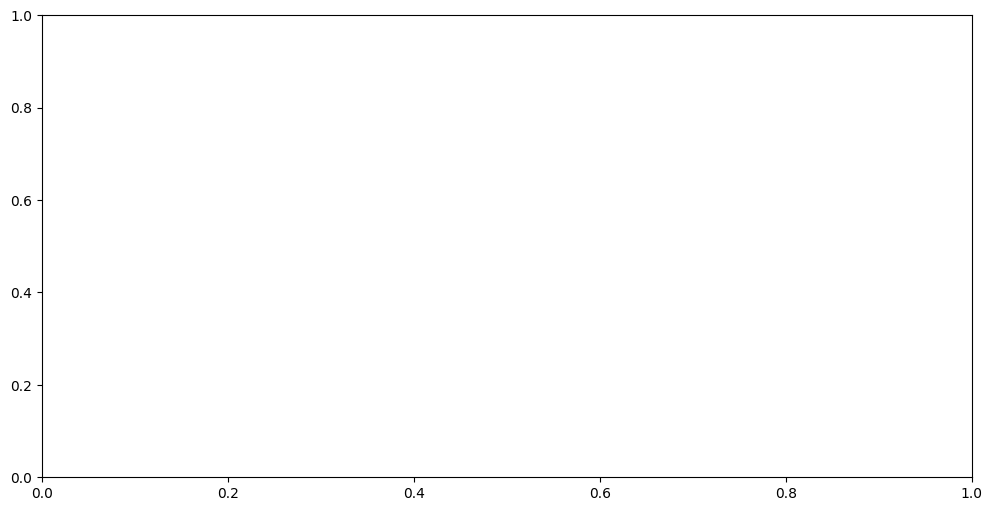

In [15]:
# Cityscapes class names
CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole', 'traffic_light',
    'traffic_sign', 'vegetation', 'terrain', 'sky', 'person', 'rider', 'car',
    'truck', 'bus', 'train', 'motorcycle', 'bicycle'
]

# Visualize per-class IoU
fig, ax = plt.subplots(figsize=(12, 6))
class_iou = metrics['class_iou']
colors = ['green' if iou > 0.5 else 'orange' if iou > 0.3 else 'red' for iou in class_iou]
bars = ax.bar(range(len(CITYSCAPES_CLASSES)), class_iou, color=colors, alpha=0.7)
ax.set_xticks(range(len(CITYSCAPES_CLASSES)))
ax.set_xticklabels(CITYSCAPES_CLASSES, rotation=45, ha='right')
ax.set_ylabel('IoU')
ax.set_title(f'Per-class IoU (mIoU: {metrics["mIoU"]:.4f})')
ax.axhline(y=metrics['mIoU'], color='blue', linestyle='--', label='mIoU', linewidth=2)
ax.legend()
plt.tight_layout()
plt.show()

# Print per-class metrics
print("\n=== Per-Class IoU ===")
for cls_name, iou in zip(CITYSCAPES_CLASSES, class_iou):
    print(f"{cls_name:20s}: {iou:.4f}")


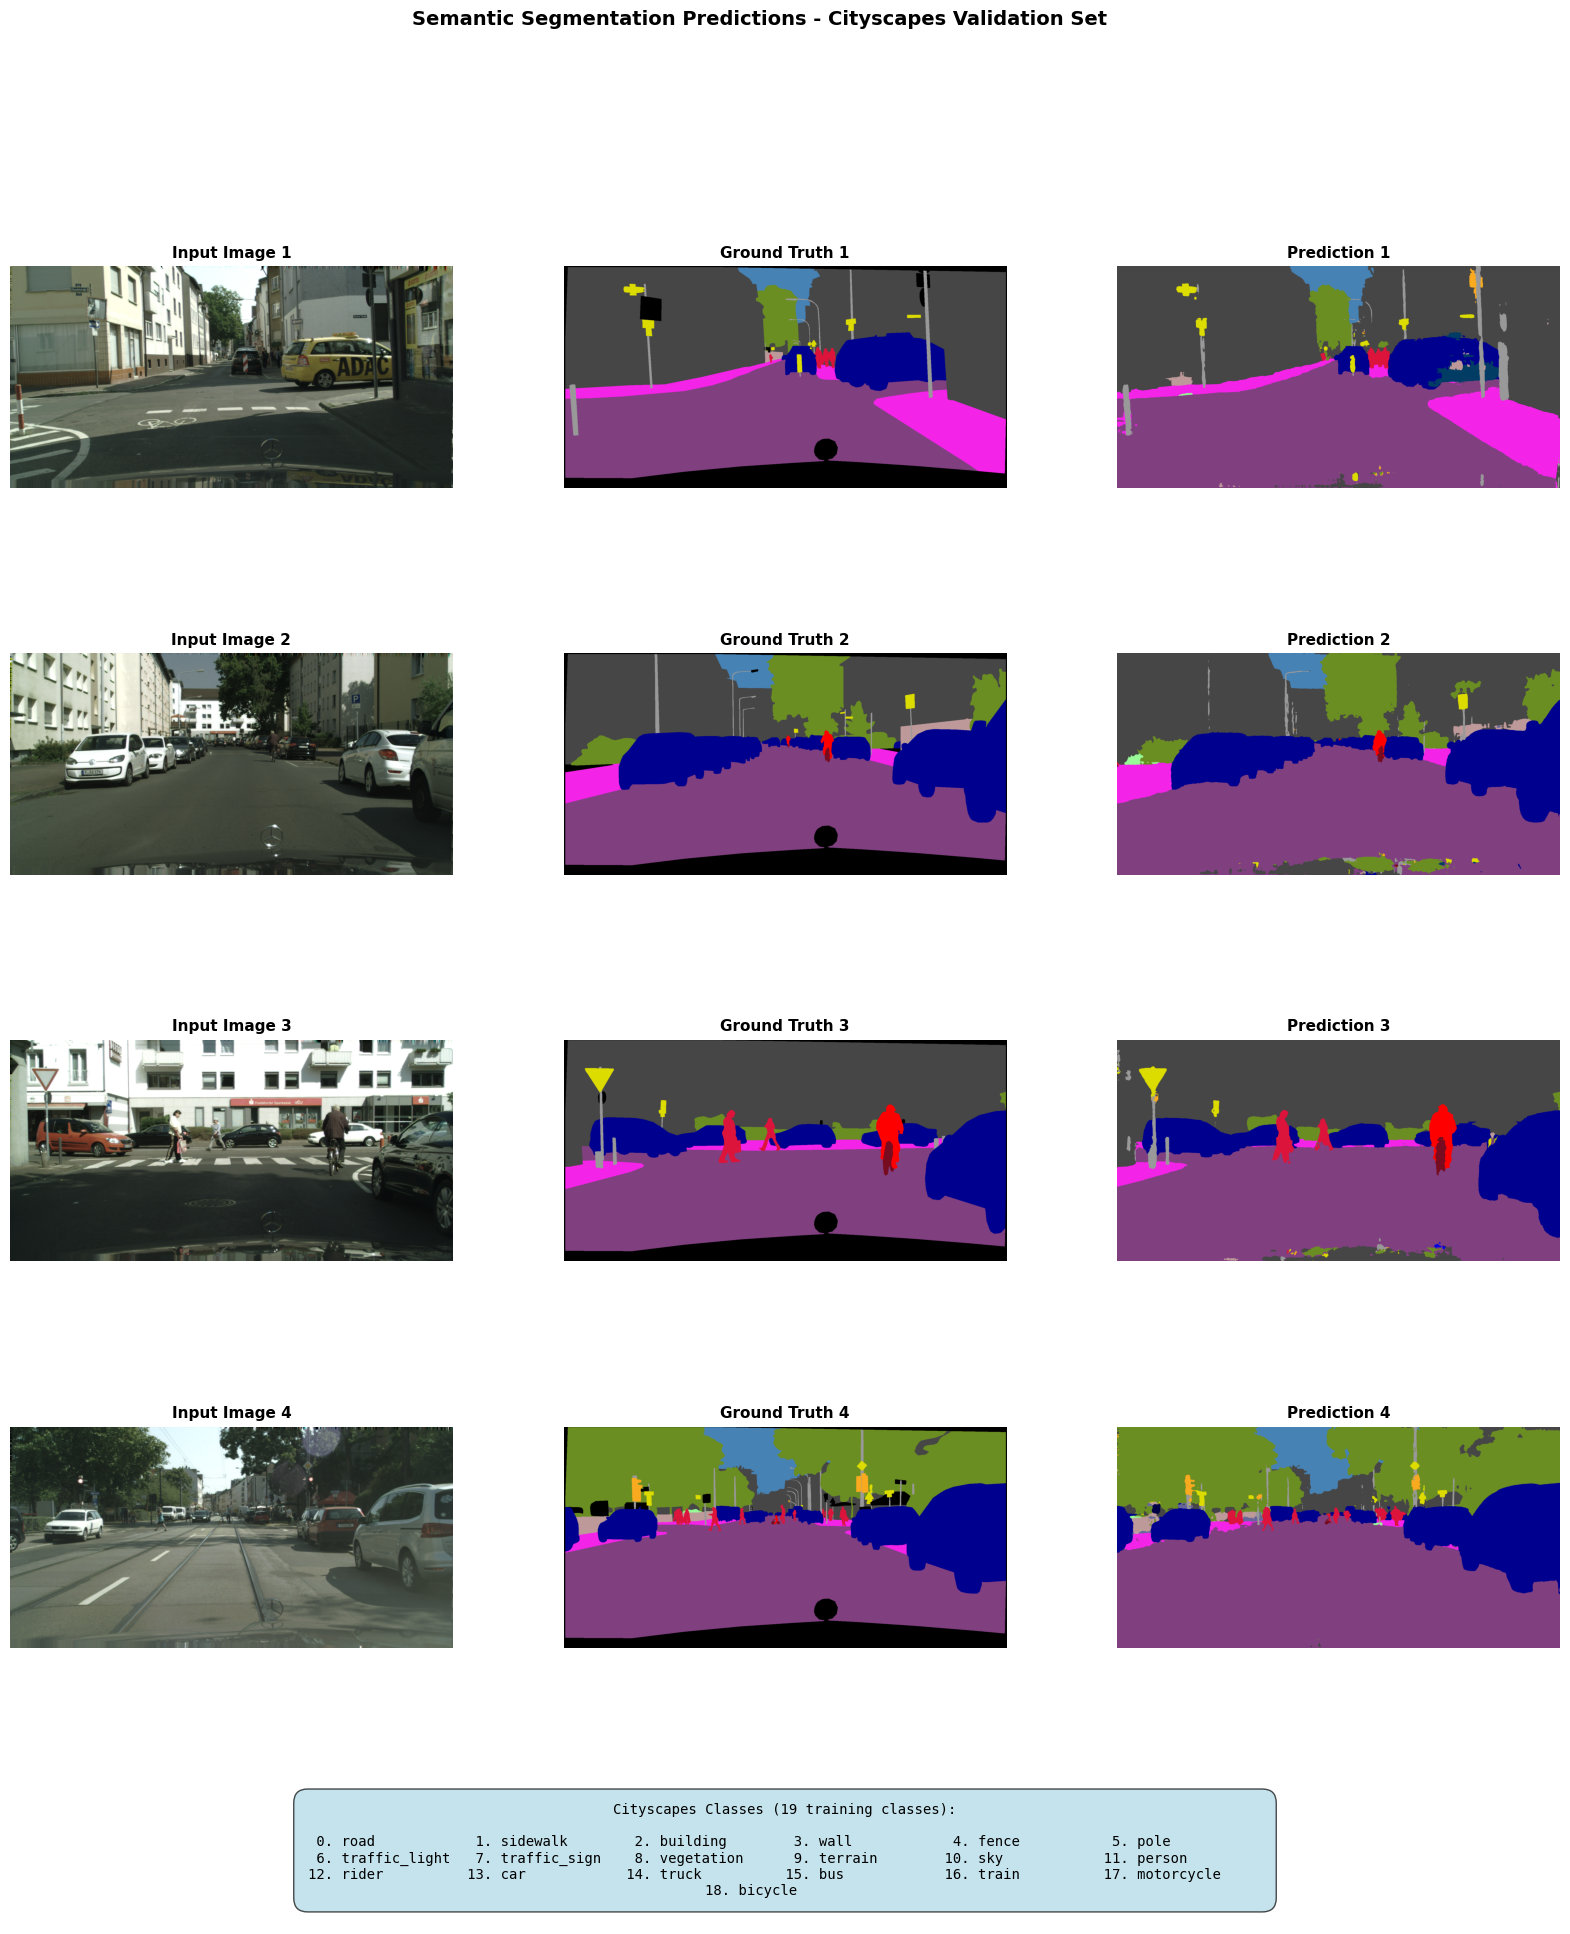

In [15]:
# Show sample predictions vs ground truth with common class legend
num_samples = 4

# Create figure with space for legend at bottom
fig = plt.figure(figsize=(20, 5*num_samples + 2))
gs = fig.add_gridspec(num_samples + 1, 3, height_ratios=[1]*num_samples + [0.5], hspace=0.35, wspace=0.25)

for i in range(num_samples):
    if i < len(predictions):
        pred, gt, image = predictions[i]
        
        # Colorize predictions
        colorized_pred = decode_fn(pred).astype('uint8')
        
        # Convert GT to train_id format for visualization
        gt_train_id = np.zeros_like(gt, dtype=np.uint8)
        for orig_id in range(len(Cityscapes.id_to_train_id)):
            mask = (gt == orig_id)
            gt_train_id[mask] = Cityscapes.id_to_train_id[orig_id]
        gt_train_id[gt == 255] = 19
        gt_rgb = decode_fn(gt_train_id).astype('uint8')
        
        # Plot images
        ax0 = fig.add_subplot(gs[i, 0])
        ax0.imshow(image)
        ax0.set_title(f'Input Image {i+1}', fontsize=11, fontweight='bold')
        ax0.axis('off')
        
        ax1 = fig.add_subplot(gs[i, 1])
        ax1.imshow(gt_rgb)
        ax1.set_title(f'Ground Truth {i+1}', fontsize=11, fontweight='bold')
        ax1.axis('off')
        
        ax2 = fig.add_subplot(gs[i, 2])
        ax2.imshow(colorized_pred)
        ax2.set_title(f'Prediction {i+1}', fontsize=11, fontweight='bold')
        ax2.axis('off')

# Add common legend at the bottom
ax_legend = fig.add_subplot(gs[num_samples, :])
ax_legend.axis('off')

# Create a formatted legend with all classes
legend_text = "Cityscapes Classes (19 training classes):\n\n"
col_width = 6
for idx, class_name in enumerate(CITYSCAPES_CLASSES):
    if idx % col_width == 0 and idx > 0:
        legend_text += "\n"
    legend_text += f"{idx:2d}. {class_name:15s}"
    
ax_legend.text(0.5, 0.5, legend_text, transform=ax_legend.transAxes,
              fontsize=10, verticalalignment='center', horizontalalignment='center',
              family='monospace',
              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7, pad=1))

plt.suptitle('Semantic Segmentation Predictions - Cityscapes Validation Set', 
             fontsize=14, fontweight='bold', y=0.98)
plt.show()

